**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 7**
Análisis de Componentes Principales (PCA)

---

*   NOMBRE: Erick Rojas Pérez
*   MATRÍCULA: A01840850

En esta actividad trabajarás con el archivo `automobile_dataset.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de automóviles, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar diferentes aspectos de los vehículos y sus precios, e incluyen información sobre el fabricante, tipo de motor, dimensiones, peso, rendimiento de combustible y otras especificaciones técnicas. Los indicadores incluidos son:

* `symboling`: Nivel de riesgo del seguro del automóvil, de -3 (bajo riesgo) a +3 (alto riesgo)
* `normalized_losses`: Pérdidas normalizadas del seguro (valor numérico de la aseguradora, algunas veces faltante)
* `make`: Marca del automóvil (por ejemplo, Audi, BMW, Honda)
* `fuel_type`: Tipo de combustible (gasolina o diésel)
* `aspiration`: Tipo de aspiración del motor (normal o turbo)
* `num_doors`: Número de puertas del automóvil (dos o cuatro)
* `body_style`: Estilo de carrocería (sedán, hatchback, wagon, hardtop, convertible)
* `drive_wheels`: Tipo de tracción (fwd: delantera, rwd: trasera, 4wd: en las cuatro ruedas)
* `engine_location`: Ubicación del motor (delantero o trasero)
* `wheel_base`: Distancia entre ejes (en pulgadas)
* `length`: Largo total del automóvil (en pulgadas)
* `width`: Ancho total del automóvil (en pulgadas)
* `height`: Altura total del automóvil (en pulgadas)
* `curb_weight`: Peso del automóvil sin carga (en libras)
* `engine_type`: Tipo de motor (OHV, OHC, DOHC, etc.)
* `num_cylinders`: Número de cilindros del motor
* `engine_size`: Tamaño del motor (en cc)
* `fuel_system`: Sistema de combustible (por ejemplo, mpfi, 2bbl, 4bbl)
* `bore`: Diámetro del cilindro (en pulgadas)
* `stroke`: Carrera del pistón (en pulgadas)
* `compression_ratio`: Relación de compresión del motor
* `horsepower`: Potencia del motor (en caballos de fuerza)
* `peak_rpm`: Revoluciones máximas por minuto
* `city_mpg`: Rendimiento de combustible en ciudad (millas por galón)
* `highway_mpg`: Rendimiento de combustible en carretera (millas por galón)
* `price`: Precio del automóvil (en dólares estadounidenses) Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 90

# Se ocultan advertencias internas de las bibliotecas (deprecaciones de
# seaborn/matplotlib) que NO afectan los resultados, según lo permitido en
# las instrucciones de la actividad.
import warnings
warnings.filterwarnings("ignore")

1. Descarga el archivo: `automobile_dataset.csv` y guarda, en un dataframe (`cars_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Al revisar los primeros registros, notarás que la columna `normalized_losses` contiene el símbolo `?`. Esto sugiere que se utilizó para indicar valores faltantes. Identifica todas las columnas que presentan este símbolo.
* Sustituye el símbolo `?` por valores faltantes (`NaN`) y convierte las columnas al tipo de dato adecuado. Esto es necesario porque la presencia del símbolo pudo haber hecho que pandas las interpretara como object, aunque en realidad no lo fueran.

In [2]:
# Cargar todos los registros del archivo en el dataframe cars_df
cars_df = pd.read_csv("automobile_dataset.csv")

# Vista previa de los primeros registros
cars_df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [3]:
# Resumen de tipos de datos
cars_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  205 non-null    str    
 2   make               205 non-null    str    
 3   fuel_type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num_doors          205 non-null    str    
 6   body_style         205 non-null    str    
 7   drive_wheels       205 non-null    str    
 8   engine_location    205 non-null    str    
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    str    
 15  num_cylinders      205 non-null    int64  
 16  engine_size        205 non-null    in

In [4]:
# Conteo de columnas numéricas y de texto (object) según la lectura original
tipos = cars_df.dtypes.apply(lambda t: "numérica" if pd.api.types.is_numeric_dtype(t) else "texto")
print("Conteo inicial de columnas por tipo:")
print(tipos.value_counts())

Conteo inicial de columnas por tipo:
texto       14
numérica    12
Name: count, dtype: int64


In [5]:
# Identificar todas las columnas que contienen el símbolo '?'
cols_con_interrogacion = [c for c in cars_df.columns if (cars_df[c] == "?").any()]
print("Columnas con el símbolo '?':")
for c in cols_con_interrogacion:
    print(f"  - {c}: {(cars_df[c] == '?').sum()} registros")

Columnas con el símbolo '?':
  - normalized_losses: 41 registros
  - bore: 4 registros
  - stroke: 4 registros
  - horsepower: 2 registros
  - peak_rpm: 2 registros


In [6]:
# Sustituir '?' por NaN y convertir esas columnas al tipo numérico adecuado
cars_df[cols_con_interrogacion] = (
    cars_df[cols_con_interrogacion]
    .replace("?", np.nan)
    .apply(pd.to_numeric)
)

# Verificación: tipos de datos tras la conversión
cars_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  164 non-null    float64
 2   make               205 non-null    str    
 3   fuel_type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num_doors          205 non-null    str    
 6   body_style         205 non-null    str    
 7   drive_wheels       205 non-null    str    
 8   engine_location    205 non-null    str    
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    str    
 15  num_cylinders      205 non-null    int64  
 16  engine_size        205 non-null    in

In [7]:
# Conteo final de columnas numéricas y de texto tras la conversión
tipos_final = cars_df.dtypes.apply(
    lambda t: "numérica" if pd.api.types.is_numeric_dtype(t) else "texto"
)
print(tipos_final.value_counts())

numérica    17
texto        9
Name: count, dtype: int64


### Conclusión — Limpieza inicial

* El conjunto tiene **205 registros y 26 columnas**.
* **Según la lectura original**, `info()` reporta **12 columnas numéricas** (7 `int64` + 5 `float64`) y **14 de texto** (`object`).
* El símbolo `?` aparece en **5 columnas** que en realidad son numéricas: `normalized_losses` (41 casos), `bore` (4), `stroke` (4), `horsepower` (2) y `peak_rpm` (2). Por contener ese carácter, pandas las había interpretado como texto.
* Tras reemplazar `?` por `NaN` y convertirlas a numéricas, el conjunto queda con **17 columnas numéricas y 9 de texto (categóricas)**, listo para el análisis.

# Análisis exploratorio de datos (univariado)

2. Antes de iniciar con el análisis univariado, verifica si hay registros duplicados e imprime el porcentaje de faltantes por columna.
* Obtén las estadísticas descriptivas, separado las numéricas (incluye asimetría y curtosis) y las categóricas (incluye tablas de frecuencias).
* Genera histogramas para las numéricas y diagramas de barras para las categóricas.

In [8]:
# Listas de columnas numéricas y categóricas (se reutilizan más adelante)
num_cols = cars_df.select_dtypes(include=np.number).columns.tolist()
cat_cols = cars_df.select_dtypes(exclude=np.number).columns.tolist()

print(f"Numéricas ({len(num_cols)}): {num_cols}")
print(f"\nCategóricas ({len(cat_cols)}): {cat_cols}")

Numéricas (17): ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'num_cylinders', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

Categóricas (9): ['make', 'fuel_type', 'aspiration', 'num_doors', 'body_style', 'drive_wheels', 'engine_location', 'engine_type', 'fuel_system']


In [9]:
# Registros duplicados
print(f"Número de registros duplicados: {cars_df.duplicated().sum()}")

# Porcentaje de valores faltantes por columna (solo las que tienen faltantes)
faltantes = (cars_df.isna().mean() * 100).round(2)
print("\nPorcentaje de faltantes por columna:")
print(faltantes[faltantes > 0].sort_values(ascending=False))

Número de registros duplicados: 0

Porcentaje de faltantes por columna:
normalized_losses    20.00
bore                  1.95
stroke                1.95
horsepower            0.98
peak_rpm              0.98
dtype: float64


In [10]:
# Estadísticas descriptivas de las variables NUMÉRICAS (incluye asimetría y curtosis)
desc_num = cars_df[num_cols].describe().T
desc_num["skewness"] = cars_df[num_cols].skew()
desc_num["kurtosis"] = cars_df[num_cols].kurt()
desc_num.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
symboling,205.0,0.83,1.25,-2.00,0.00,1.00,2.00,3.00,0.21,-0.68
normalized_losses,164.0,122.00,35.44,65.00,94.00,115.00,150.00,256.00,0.77,0.53
wheel_base,205.0,98.76,6.02,86.60,94.50,97.00,102.40,120.90,1.05,1.02
length,205.0,174.05,12.34,141.10,166.30,173.20,183.10,208.10,0.16,-0.08
width,205.0,65.91,2.15,60.30,64.10,65.50,66.90,72.30,0.90,0.70
height,205.0,53.72,2.44,47.80,52.00,54.10,55.50,59.80,0.06,-0.44
curb_weight,205.0,2555.57,520.68,1488.00,2145.00,2414.00,2935.00,4066.00,0.68,-0.04
num_cylinders,205.0,4.38,1.08,2.00,4.00,4.00,4.00,12.00,2.82,13.71
engine_size,205.0,126.91,41.64,61.00,97.00,120.00,141.00,326.00,1.95,5.31
bore,201.0,3.33,0.27,2.54,3.15,3.31,3.59,3.94,0.02,-0.83


In [11]:
# Estadísticas descriptivas de las variables CATEGÓRICAS
cars_df[cat_cols].describe().T

,count,unique,top,freq
make,205,22,toyota,32
fuel_type,205,2,gas,185
aspiration,205,2,std,168
num_doors,205,2,four,116
body_style,205,5,sedan,96
drive_wheels,205,3,fwd,120
engine_location,205,2,front,202
engine_type,205,7,ohc,148
fuel_system,205,8,mpfi,94


In [12]:
# Tablas de frecuencias de cada variable categórica
for c in cat_cols:
    print(f"--- {c} ---")
    print(cars_df[c].value_counts())
    print()

--- make ---
make
toyota           32
nissan           18
mazda            17
honda            13
mitsubishi       13
subaru           12
volkswagen       12
peugot           11
volvo            11
dodge             9
bmw               8
mercedes-benz     8
audi              7
plymouth          7
saab              6
porsche           5
isuzu             4
alfa-romero       3
chevrolet         3
jaguar            3
renault           2
mercury           1
Name: count, dtype: int64

--- fuel_type ---
fuel_type
gas       185
diesel     20
Name: count, dtype: int64

--- aspiration ---
aspiration
std      168
turbo     37
Name: count, dtype: int64

--- num_doors ---
num_doors
four    116
two      89
Name: count, dtype: int64

--- body_style ---
body_style
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

--- drive_wheels ---
drive_wheels
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64

--- engine_location ---
engin

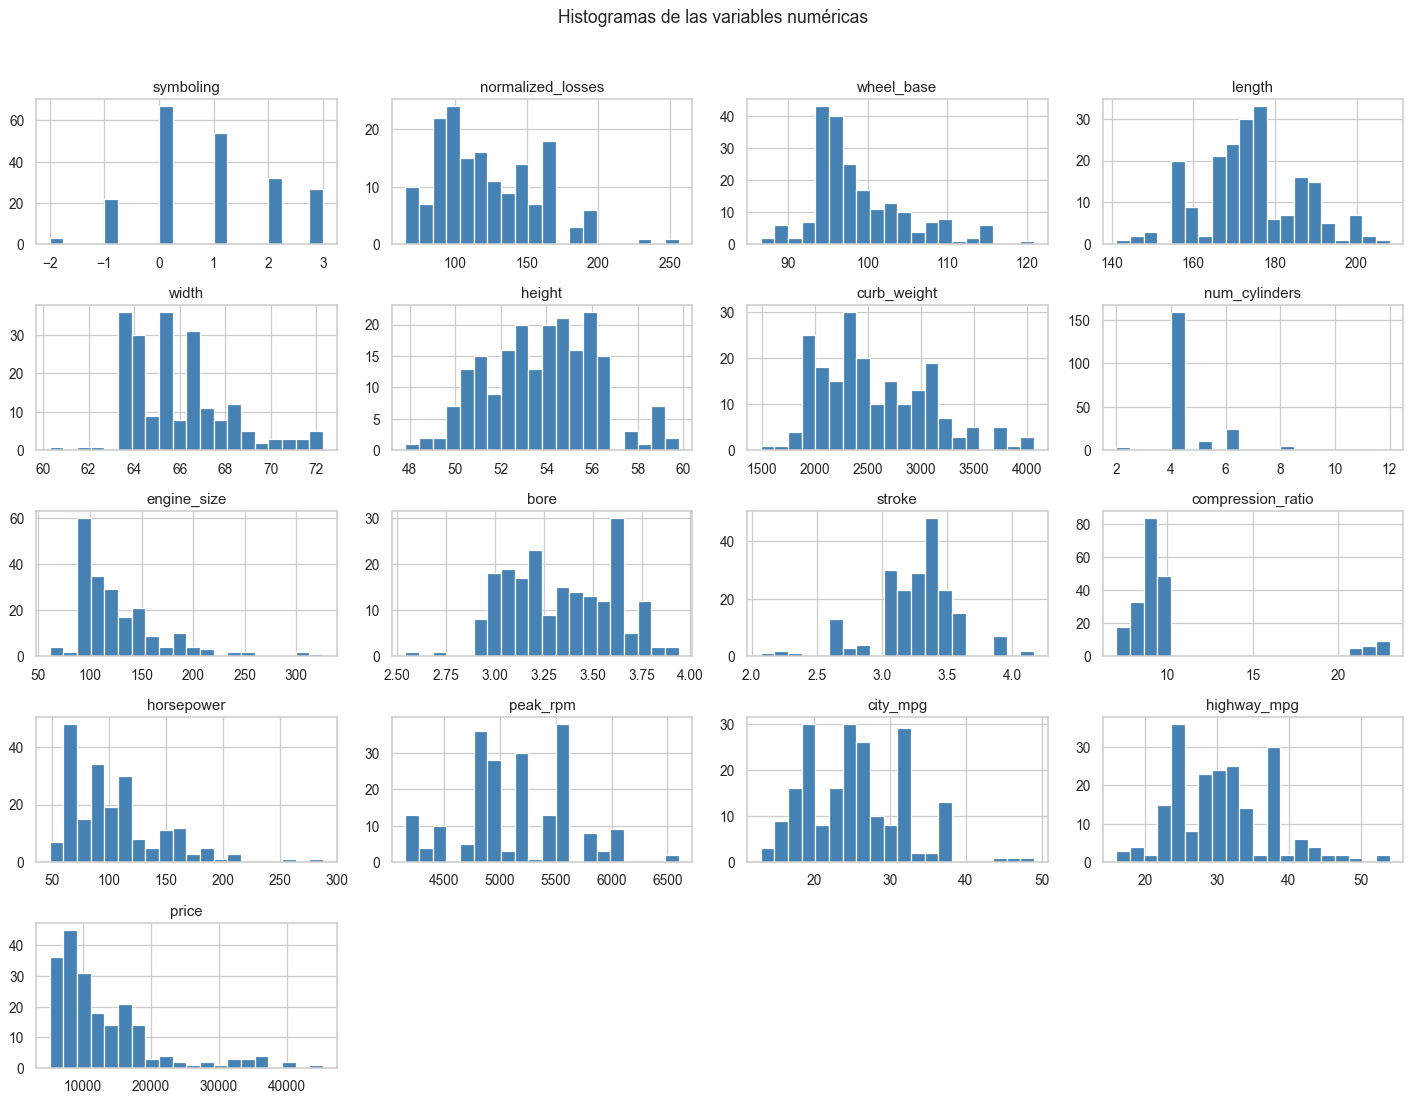

In [13]:
# Histogramas de las variables numéricas
cars_df[num_cols].hist(figsize=(16, 12), bins=20, color="steelblue", edgecolor="white")
plt.suptitle("Histogramas de las variables numéricas", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

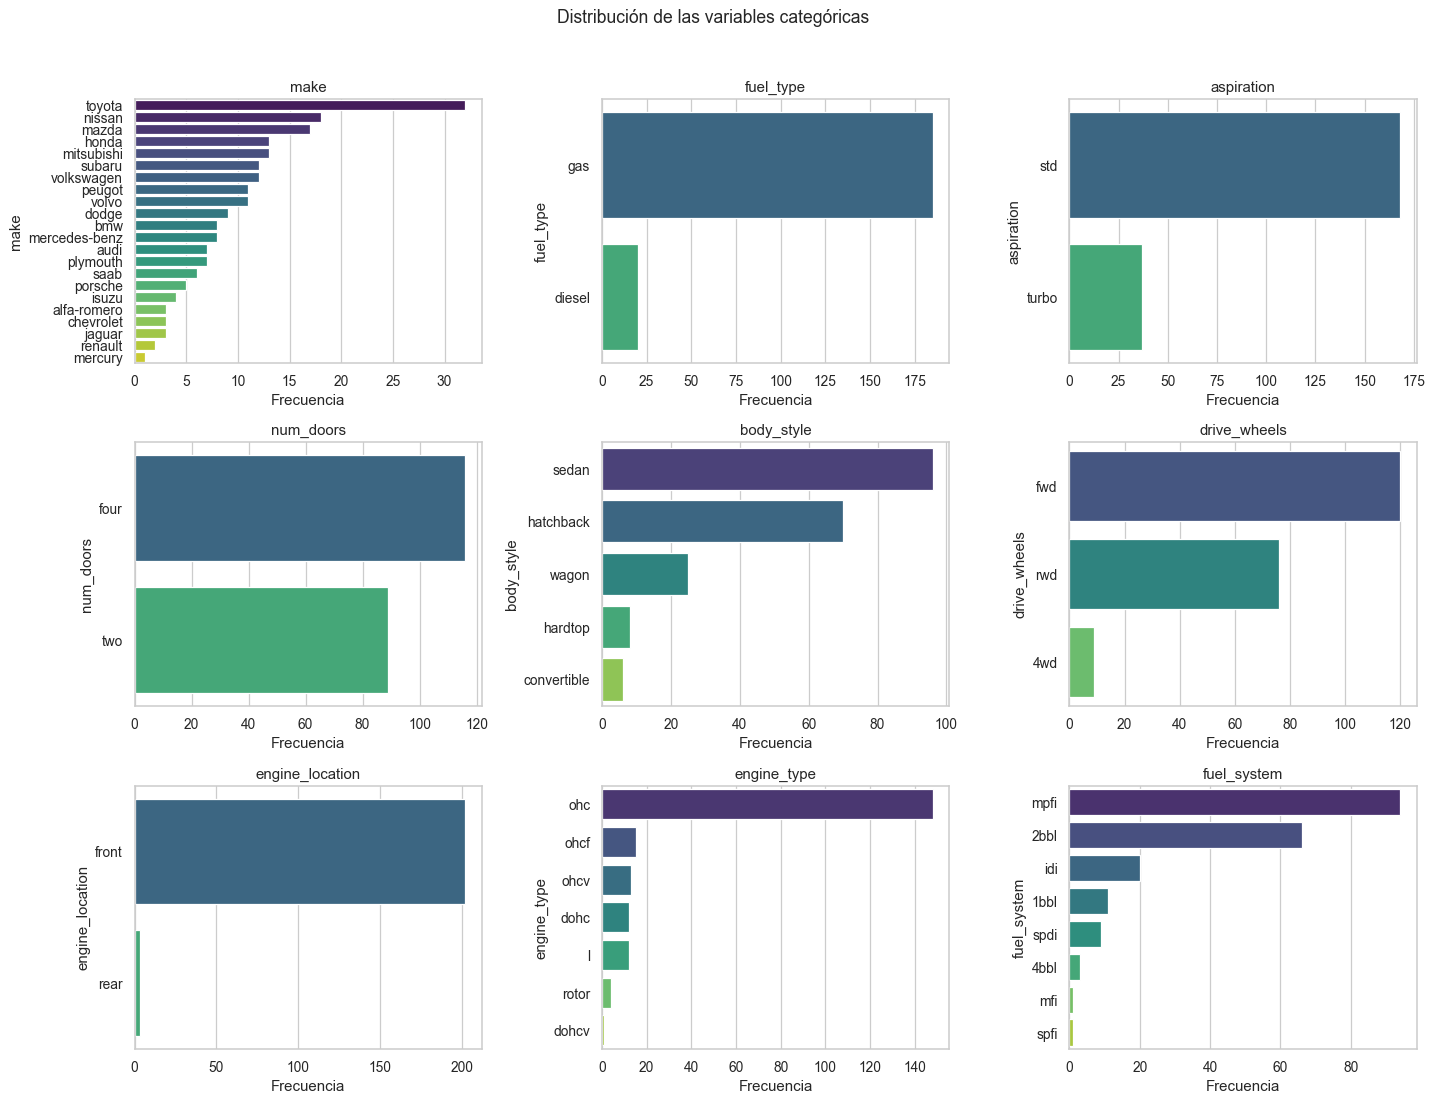

In [14]:
# Diagramas de barras de las variables categóricas
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, c in zip(axes.ravel(), cat_cols):
    vc = cars_df[c].value_counts()
    sns.barplot(x=vc.values, y=vc.index, hue=vc.index, palette="viridis",
                legend=False, ax=ax)
    ax.set_title(c)
    ax.set_xlabel("Frecuencia")
# Ocultar ejes sobrantes
for ax in axes.ravel()[len(cat_cols):]:
    ax.axis("off")
plt.suptitle("Distribución de las variables categóricas", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Conclusión — Análisis univariado

* **No existen registros duplicados** (0 duplicados).
* La única variable con un porcentaje alto de faltantes es **`normalized_losses` (20%)**; `bore` y `stroke` tienen ≈2% y `horsepower`/`peak_rpm` < 1%. Ninguna columna requiere ser eliminada por faltantes.
* Las variables numéricas muestran **fuerte asimetría positiva** en `price`, `engine_size`, `horsepower` y `compression_ratio` (presencia de autos de gama alta y motores diésel), lo que se confirma en los histogramas con colas hacia la derecha.
* En las categóricas predominan los autos de **gasolina**, **aspiración estándar**, **4 puertas**, carrocería **sedán**, tracción **fwd** y motor **ohc**; los fabricantes más frecuentes son Toyota, Nissan y Mazda. Varias categorías están muy desbalanceadas (p. ej. `engine_location` es casi siempre `front`).

# Análisis exploratorio de datos (bivariado)

3. Genera algunos gráficos bivariados para familiarizarte con el conjunto de datos:
* Gráfico de barras apiladas normalizadas que muestra la distribución de los tipos de tracción para cada fabricante.
* Diagrama de cajas para visualizar cómo se distribuye el precio de los automóviles según el estilo de carrocería. Esto permitirá comparar la mediana, los cuartiles y la presencia de valores atípicos entre los diferentes tipos de carrocería.
* Gráfico de barras que muestre los 10 automóviles más caros, ordenados de mayor a menor precio, con cada barra diferenciada con color por fabricante.
* Diagrama de dispersión para explorar la relación entre el tamaño del motor y el precio de los automóviles. Diferencia con colores los puntos según el tipo de aspiración y con el tamaño de los puntos el número de puertas.

**Nota.** Debes incluir en cada gráfico una conclusión de lo observado.

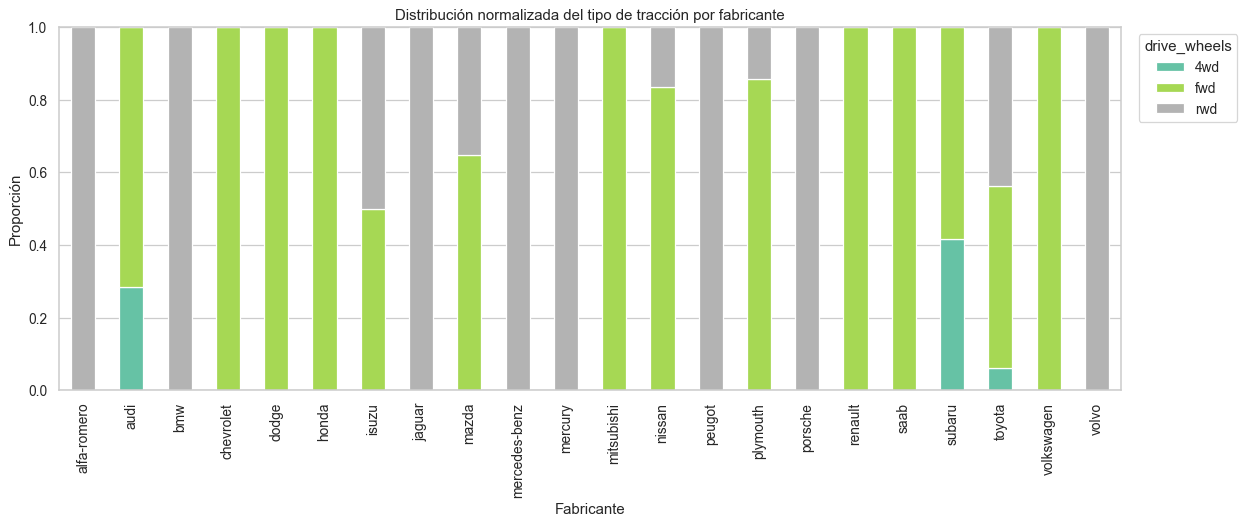

In [15]:
# a) Barras apiladas normalizadas: distribución de tracción por fabricante
ct = pd.crosstab(cars_df["make"], cars_df["drive_wheels"], normalize="index")
ct.plot(kind="bar", stacked=True, figsize=(14, 6), colormap="Set2")
plt.title("Distribución normalizada del tipo de tracción por fabricante")
plt.ylabel("Proporción")
plt.xlabel("Fabricante")
plt.legend(title="drive_wheels", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Conclusión (a).** La tracción delantera (`fwd`) domina en marcas económicas y de volumen (Honda, Mazda, Mitsubishi, Nissan, Toyota, Volkswagen). En cambio, marcas premium o deportivas como **Mercedes-Benz, BMW, Jaguar y Porsche usan exclusivamente tracción trasera (`rwd`)**, y solo unas pocas (Audi, Subaru, Toyota) ofrecen tracción `4wd`. El tipo de tracción está claramente asociado al posicionamiento de la marca.

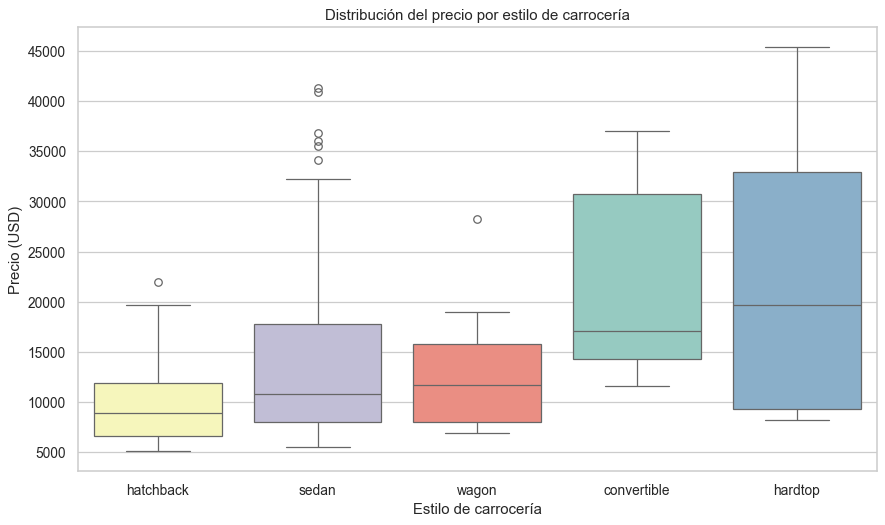

In [16]:
# b) Diagrama de cajas: precio según estilo de carrocería
plt.figure(figsize=(10, 6))
orden = cars_df.groupby("body_style")["price"].median().sort_values().index
sns.boxplot(data=cars_df, x="body_style", y="price", order=orden,
            hue="body_style", palette="Set3", legend=False)
plt.title("Distribución del precio por estilo de carrocería")
plt.xlabel("Estilo de carrocería")
plt.ylabel("Precio (USD)")
plt.tight_layout()
plt.show()

**Conclusión (b).** Los estilos **`hardtop` y `convertible`** presentan las **medianas de precio más altas** y mayor dispersión, mientras que `hatchback` es el más económico. `sedan` y `wagon` se ubican en un rango intermedio. Se observan **valores atípicos caros** sobre todo en `sedan` y `hatchback` (autos premium con esas carrocerías), lo que indica que el estilo de carrocería por sí solo no determina el precio.

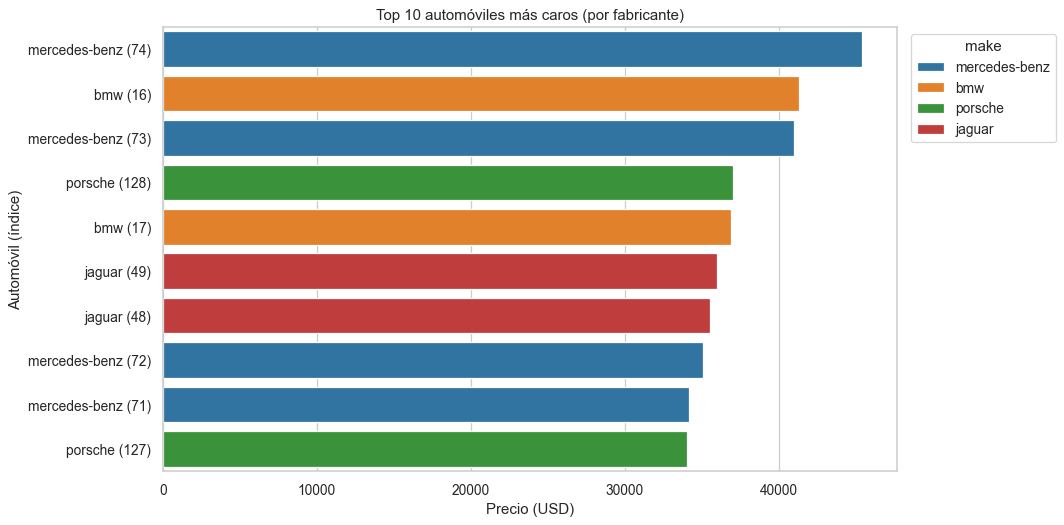

In [17]:
# c) Top 10 automóviles más caros, coloreados por fabricante
top10 = cars_df.nlargest(10, "price").copy()
top10["etiqueta"] = top10["make"] + " (" + top10.index.astype(str) + ")"
plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x="price", y="etiqueta", hue="make",
            dodge=False, palette="tab10")
plt.title("Top 10 automóviles más caros (por fabricante)")
plt.xlabel("Precio (USD)")
plt.ylabel("Automóvil (índice)")
plt.legend(title="make", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Conclusión (c).** Los 10 automóviles más caros están dominados por **Mercedes-Benz, BMW, Jaguar y Porsche**, con precios que superan los **\$30,000** y llegan a ≈\$45,400. Esto confirma que el segmento de lujo está concentrado en pocas marcas europeas y refuerza la relación entre fabricante y precio observada antes.

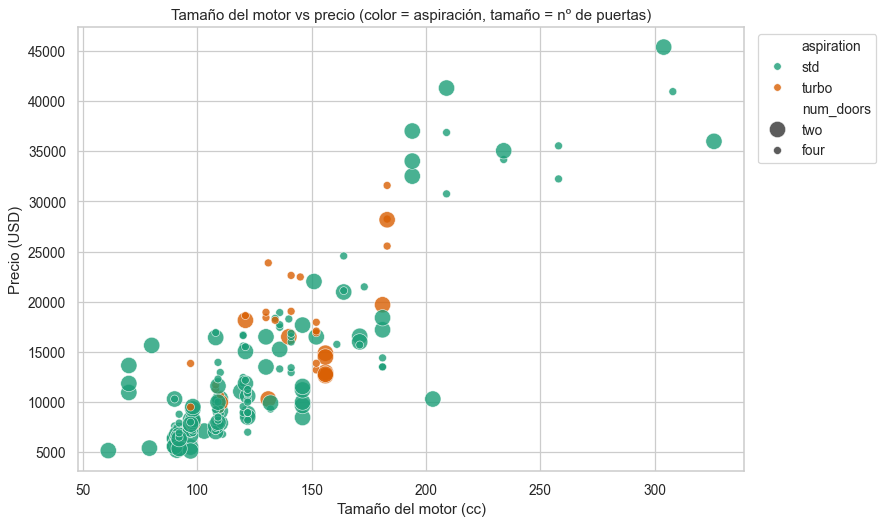

In [18]:
# d) Dispersión: tamaño del motor vs precio (color = aspiración, tamaño = num_doors)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cars_df, x="engine_size", y="price",
                hue="aspiration", size="num_doors", sizes=(40, 170),
                alpha=0.8, palette="Dark2")
plt.title("Tamaño del motor vs precio (color = aspiración, tamaño = nº de puertas)")
plt.xlabel("Tamaño del motor (cc)")
plt.ylabel("Precio (USD)")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Conclusión (d).** Existe una **relación positiva clara** entre el tamaño del motor y el precio: motores más grandes implican autos más caros. Los vehículos con aspiración **`turbo`** tienden a ubicarse en precios más altos para un mismo tamaño de motor. El número de puertas no muestra un patrón fuerte respecto al precio, aunque los autos más caros y de motor grande suelen ser de **dos puertas** (deportivos/cupés).

4. Genera un mapa de calor de la matriz de correlación entre las variables numéricas del conjunto de datos, mostrando los valores de correlación en cada celda.
* ¿Cuáles son las tres variables más correlacionadas con el precio?

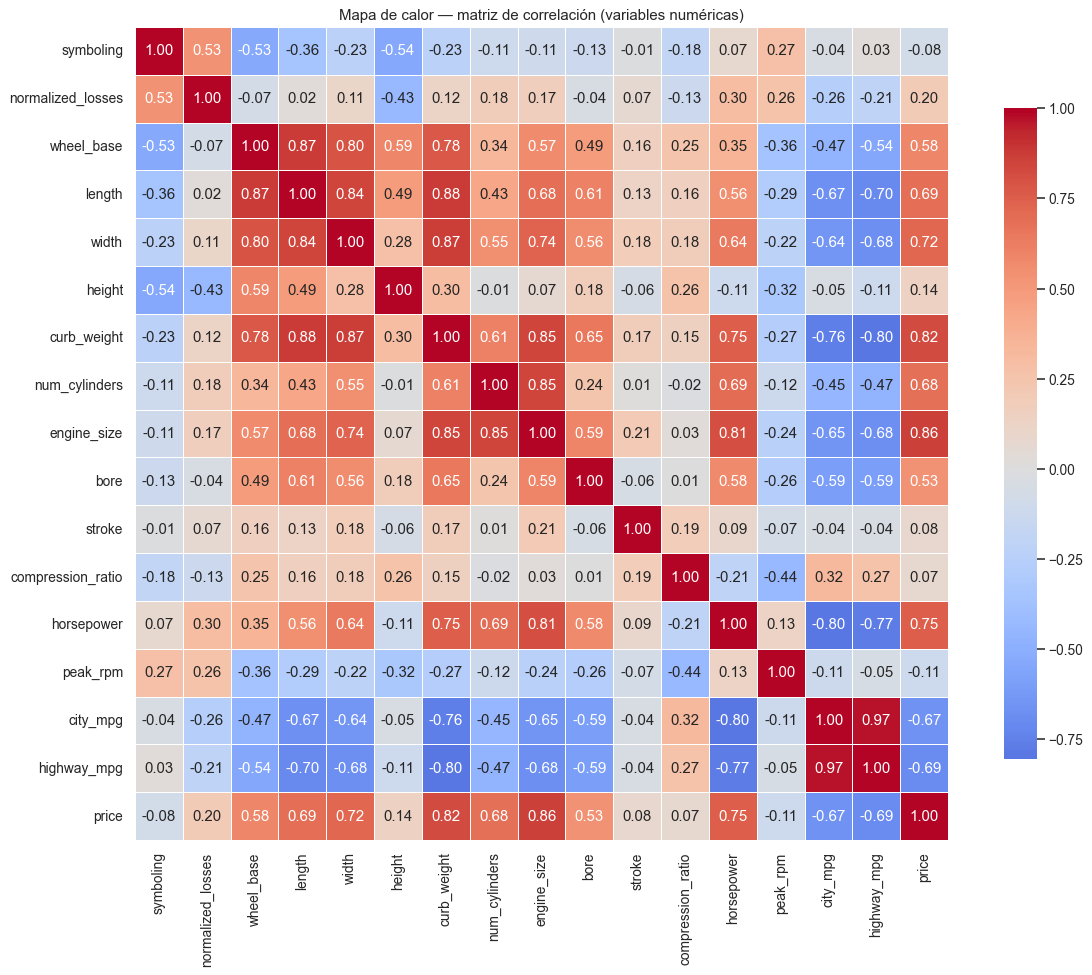

In [19]:
# Matriz de correlación de las variables numéricas
corr = cars_df[num_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Mapa de calor — matriz de correlación (variables numéricas)")
plt.tight_layout()
plt.show()

In [20]:
# Tres variables más correlacionadas con el precio (en valor absoluto)
top3 = corr["price"].drop("price").abs().sort_values(ascending=False).head(3)
print("Tres variables más correlacionadas con el precio:")
print(corr["price"][top3.index].round(3))

Tres variables más correlacionadas con el precio:
engine_size    0.86
curb_weight    0.82
horsepower     0.75
Name: price, dtype: float64


### Conclusión — Matriz de correlación

Las **tres variables más correlacionadas con el precio** son:

1. **`engine_size`** ≈ **0.86**
2. **`curb_weight`** ≈ **0.82**
3. **`horsepower`** ≈ **0.75**

Es decir, el precio crece principalmente con el tamaño del motor, el peso y la potencia. Además se observan **fuertes correlaciones entre los predictores** (p. ej. `curb_weight`–`length`–`width`–`engine_size`, y `city_mpg`–`highway_mpg` ≈ 0.97), lo que evidencia **multicolinealidad** y justifica el uso de PCA.

En el análisis de correlación se observa que existen muchos pares de variables altamente correlacionadas, lo que puede afectar el desempeño de los modelos de regresión. PCA resulta útil no solo para reducir la dimensionalidad, sino también porque los componentes principales son ortogonales entre sí, es decir, tienen correlación cero, evitando problemas de multicolinealidad. Esto lo podrás comprobrar más adelante.

# Ingeniería de características

5. Realiza las siguientes operaciones de ingeniería de características en las variables numéricas:
* Considera `price` como la variable objetivo y guárdala en `y`. Separa los predictores numéricos en `X`. Con base en estos datos, ¿cuántos componentes principales se generarán al aplicar PCA?
* Aplica `SimpleImputer` sobre `X` para tratar los valores faltantes, justificando la estrategia de imputación seleccionada.
* Realiza el escalamiento del conjunto `X` ya imputado, para que todas las variables contribuyan equitativamente y ninguna domine el análisis por tener una escala mayor.

PCA está diseñado principalmente para variables numéricas y funciona encontrando combinaciones lineales de las variables originales que capturan la mayor varianza en los datos. Normalmente se recomienda eliminar las variables categóricas antes de aplicar PCA y luego concatenarlas nuevamente con los resultados de PCA si se desea.

In [21]:
# Variable objetivo (y) y predictores numéricos (X, sin price)
y = cars_df["price"]
X = cars_df[num_cols].drop(columns=["price"])

print(f"Forma de X (predictores numéricos): {X.shape}")
print(f"Número de componentes principales que generará PCA: {X.shape[1]}")

Forma de X (predictores numéricos): (205, 16)
Número de componentes principales que generará PCA: 16


In [ ]:
# Imputación de faltantes con la MEDIANA.
# Justificación: varias variables (price-relacionadas, normalized_losses) son
# asimétricas y contienen valores atípicos; la mediana es robusta frente a
# outliers y no distorsiona la distribución como podría hacerlo la media.
imputer = SimpleImputer(strategy="median")

imputer = SimpleImputer(strategy="median")


X_imputado = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

print("Faltantes después de imputar:", int(X_imputado.isna().sum().sum()))

Faltantes después de imputar: 0


In [23]:
# Escalamiento estándar (media 0, desviación 1) para que ninguna variable
# domine por tener una escala mayor (p. ej. curb_weight vs compression_ratio).
scaler = StandardScaler()
X_escalado = pd.DataFrame(scaler.fit_transform(X_imputado),
                          columns=X.columns, index=X.index)
X_escalado.describe().round(2).T[["mean", "std", "min", "max"]]

,mean,std,min,max
symboling,0.0,1.0,-2.28,1.74
normalized_losses,0.0,1.0,-1.75,4.27
wheel_base,-0.0,1.0,-2.02,3.69
length,0.0,1.0,-2.68,2.77
width,0.0,1.0,-2.62,2.99
height,-0.0,1.0,-2.43,2.49
curb_weight,0.0,1.0,-2.06,2.91
num_cylinders,-0.0,1.0,-2.21,7.07
engine_size,0.0,1.0,-1.59,4.79
bore,0.0,1.0,-2.92,2.26


### Conclusión — Imputación y escalamiento

* Se definió `price` como variable objetivo (`y`) y los **16 predictores numéricos** restantes como `X`. Por lo tanto, **PCA generará 16 componentes principales** (uno por cada variable de entrada).
* La imputación se realizó con la **mediana** porque es **robusta ante valores atípicos y distribuciones asimétricas** (presentes en estas variables), evitando el sesgo que introduciría la media.
* Tras el escalamiento estándar, todas las variables tienen **media ≈ 0 y desviación estándar = 1**, garantizando que contribuyan equitativamente al PCA.

6. Aplica `PCA` a los datos escalados para proyectarlos en el nuevo espacio de vectores.
* Asigna nombres descriptivos a los componentes principales en el dataframe resultante, utilizando la convención PC1, PC2, PC3, y así sucesivamente.
* Genera un mapa de calor con la matriz de correlaciones de los componentes principales para verificar que sean independientes entre sí.

In [24]:
# Aplicar PCA sobre los datos escalados
pca = PCA()
componentes = pca.fit_transform(X_escalado)

# Nombres descriptivos PC1, PC2, ...
nombres_pc = [f"PC{i}" for i in range(1, X_escalado.shape[1] + 1)]
pca_df = pd.DataFrame(componentes, columns=nombres_pc, index=X.index)
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
0,-0.918474,-2.397150,-0.410501,1.416623,-1.822817,1.203190,0.369729,0.288788,-1.088415,-0.347735,-0.474581,0.267610,-0.273617,0.362346,0.185204,0.003853
1,-0.918474,-2.397150,-0.410501,1.416623,-1.822817,1.203190,0.369729,0.288788,-1.088415,-0.347735,-0.474581,0.267610,-0.273617,0.362346,0.185204,0.003853
2,0.634430,-1.372747,0.872496,0.998222,1.834717,-0.774751,-0.515065,1.370499,-1.130802,-1.013703,0.502983,0.657052,0.174955,-0.008520,0.118635,-0.111688
3,-0.361470,-0.919214,0.451578,-1.489124,-0.269938,-0.789900,0.000484,0.400032,0.293338,0.168137,0.039239,-0.022832,-0.078891,-0.391786,0.009265,0.053641
4,1.172393,-1.794960,0.183773,-1.083812,0.113486,-0.861858,-0.353900,0.870186,0.015429,-0.447054,-0.055376,-0.416053,-0.049431,0.079357,-0.198402,0.046303


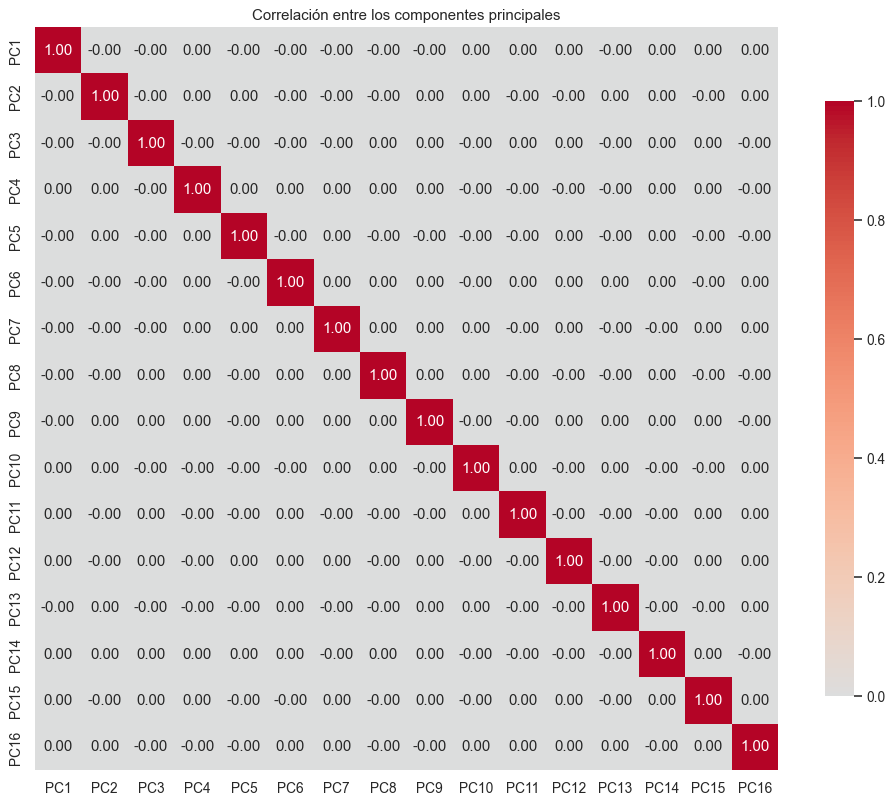

In [25]:
# Mapa de calor de la correlación entre componentes principales
plt.figure(figsize=(11, 9))
sns.heatmap(pca_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title("Correlación entre los componentes principales")
plt.tight_layout()
plt.show()

### Conclusión — Proyección PCA

El mapa de calor muestra **1.0 en la diagonal y valores ≈ 0 fuera de ella** (del orden de 1e-16). Esto confirma que los componentes principales son **ortogonales / linealmente independientes** entre sí: a diferencia de las variables originales (con alta multicolinealidad), los nuevos componentes **no están correlacionados**, que es precisamente la ventaja buscada con PCA.

7. Obtén el porcentaje de varianza explicada por cada componente.
* Grafica la curva de varianza acumulada para determinar el número mínimo de componentes principales que explican más del 90% de la varianza total.

In [26]:
# Porcentaje de varianza explicada por cada componente
var_exp = pca.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

tabla_var = pd.DataFrame({
    "Componente": nombres_pc,
    "Varianza explicada (%)": (var_exp * 100).round(2),
    "Varianza acumulada (%)": (var_acum * 100).round(2),
})
print(tabla_var.to_string(index=False))

# Número mínimo de componentes para superar el 90%
n_componentes = int(np.argmax(var_acum >= 0.90) + 1)
print(f"\nNúmero mínimo de componentes para explicar >90%: {n_componentes}")

Componente  Varianza explicada (%)  Varianza acumulada (%)
       PC1                   44.55                   44.55
       PC2                   17.93                   62.48
       PC3                    8.58                   71.05
       PC4                    6.44                   77.49
       PC5                    5.74                   83.23
       PC6                    4.78                   88.01
       PC7                    3.25                   91.26
       PC8                    2.73                   93.98
       PC9                    1.94                   95.92
      PC10                    1.55                   97.48
      PC11                    0.75                   98.23
      PC12                    0.63                   98.86
      PC13                    0.51                   99.37
      PC14                    0.35                   99.73
      PC15                    0.16                   99.88
      PC16                    0.12                  100.

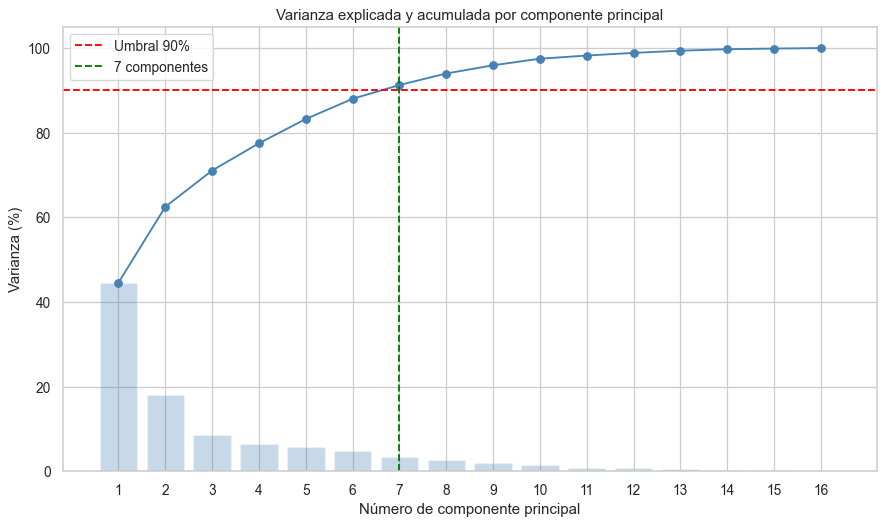

In [27]:
# Curva de varianza acumulada
plt.figure(figsize=(10, 6))
x = range(1, len(var_acum) + 1)
plt.plot(x, var_acum * 100, marker="o", color="steelblue")
plt.bar(x, var_exp * 100, alpha=0.3, color="steelblue")
plt.axhline(90, color="red", linestyle="--", label="Umbral 90%")
plt.axvline(n_componentes, color="green", linestyle="--",
            label=f"{n_componentes} componentes")
plt.title("Varianza explicada y acumulada por componente principal")
plt.xlabel("Número de componente principal")
plt.ylabel("Varianza (%)")
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()

### Conclusión — Varianza explicada

* El **PC1 explica el 44.6%** de la varianza y el **PC2 el 17.9%**; juntos superan el 62%.
* Se necesitan **7 componentes principales** para explicar **más del 90%** de la varianza total (acumulan **91.3%**).
* Esto significa que podemos **reducir de 16 variables a 7 componentes** perdiendo menos del 9% de la información, lo que simplifica notablemente el conjunto de datos.

8. Imprime la información de los componentes seleccionados (cargas o pesos de las variables originales) para interpretar qué variables contribuyen más a cada componente principal.
* Dibuja un diagrama de barras que muestre qué variables originales aportan más al primer componente principal (PC1), para visualizar su influencia relativa.

In [28]:
# Cargas (loadings): contribución de cada variable original a cada componente
loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=nombres_pc)

# Solo los componentes seleccionados (los que superan el 90%)
pcs_sel = nombres_pc[:n_componentes]
print(f"Cargas de los {n_componentes} componentes seleccionados:")
loadings[pcs_sel].round(3)

Cargas de los 7 componentes seleccionados:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
symboling,-0.097,-0.403,0.265,-0.072,-0.366,0.173,0.128
normalized_losses,0.016,-0.331,0.308,-0.343,-0.376,-0.492,-0.323
wheel_base,0.298,0.265,-0.029,-0.228,-0.004,-0.183,-0.106
length,0.338,0.139,-0.044,-0.194,-0.074,-0.082,-0.009
width,0.334,0.055,0.109,-0.098,-0.016,-0.107,0.140
height,0.114,0.422,-0.282,-0.186,-0.017,-0.214,-0.003
curb_weight,0.362,0.022,0.080,-0.025,-0.042,-0.014,0.061
num_cylinders,0.245,-0.114,0.177,0.552,0.237,-0.354,-0.068
engine_size,0.330,-0.082,0.199,0.296,0.109,0.016,-0.073
bore,0.263,0.003,-0.138,0.041,-0.373,0.512,0.126


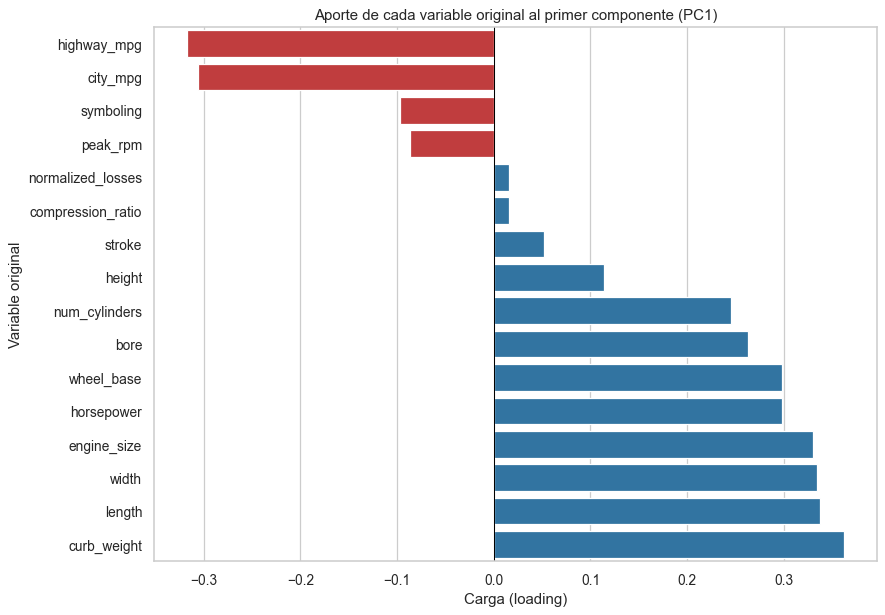

In [29]:
# Diagrama de barras: aporte de cada variable a PC1 (ordenado por magnitud)
pc1 = loadings["PC1"].sort_values()
plt.figure(figsize=(10, 7))
colores = ["#d62728" if v < 0 else "#1f77b4" for v in pc1.values]
sns.barplot(x=pc1.values, y=pc1.index, hue=pc1.index, palette=colores, legend=False)
plt.title("Aporte de cada variable original al primer componente (PC1)")
plt.xlabel("Carga (loading)")
plt.ylabel("Variable original")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### Conclusión — Interpretación de los componentes

* **PC1** está dominado por las variables de **tamaño, peso y potencia**: `curb_weight` (0.36), `length`, `width`, `engine_size`, `horsepower` (cargas positivas) frente a `city_mpg` y `highway_mpg` (cargas negativas). Se interpreta como un eje de **"tamaño/potencia del vehículo vs. eficiencia de combustible"**: autos grandes y potentes en un extremo, autos pequeños y económicos en el otro.
* **PC2** recoge sobre todo `height`, `symboling`, `peak_rpm` y `compression_ratio`, asociándose a un eje de **tipo de carrocería/riesgo y características del motor** (incluida la diferencia gasolina–diésel a través de `compression_ratio`).
* En conjunto, los primeros componentes resumen la mayor parte de la variabilidad técnica de los automóviles.

9. Codifica las variables categóricas mediante *One-Hot Encoding* y utiliza el parámetro `drop='first'` para evitar problemas de multicolinealidad entre las variables dummy generadas.

In [30]:
# One-Hot Encoding de las variables categóricas con drop='first'
ohe = OneHotEncoder(drop="first", sparse_output=False)
cat_encoded = ohe.fit_transform(cars_df[cat_cols])
cat_df = pd.DataFrame(cat_encoded,
                      columns=ohe.get_feature_names_out(cat_cols),
                      index=cars_df.index)

print(f"Variables categóricas originales: {len(cat_cols)}")
print(f"Columnas dummy generadas (con drop='first'): {cat_df.shape[1]}")
cat_df.head()

Variables categóricas originales: 9
Columnas dummy generadas (con drop='first'): 44


,make_audi,make_bmw,make_chevrolet,make_dodge,make_honda,make_isuzu,make_jaguar,make_mazda,make_mercedes-benz,make_mercury,...,engine_type_ohcf,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Conclusión — Codificación

Las **9 variables categóricas** se transformaron mediante *One-Hot Encoding* en **44 columnas dummy**. El parámetro `drop='first'` elimina la primera categoría de cada variable (que queda como categoría de referencia), evitando la **trampa de las variables dummy** (multicolinealidad perfecta entre las columnas generadas).

10. Conjunta, en un dataframe, las valores proyectados en los componentes seleccionados (mínimo), las transformaciones obtenidas de las variables categóricas y la variable de salida.
* Almacena el dataframe resultante en archivo.

In [31]:
# Conjuntar: componentes seleccionados + variables categóricas codificadas + target
df_final = pd.concat([pca_df[pcs_sel], cat_df, y.rename("price")], axis=1)

print(f"Forma del dataframe final: {df_final.shape}")
print(f"  - {len(pcs_sel)} componentes principales")
print(f"  - {cat_df.shape[1]} variables categóricas codificadas")
print(f"  - 1 variable objetivo (price)")
df_final.head()

Forma del dataframe final: (205, 52)
  - 7 componentes principales
  - 44 variables categóricas codificadas
  - 1 variable objetivo (price)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,make_audi,make_bmw,make_chevrolet,...,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi,price
0,-0.918474,-2.397150,-0.410501,1.416623,-1.822817,1.203190,0.369729,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13495
1,-0.918474,-2.397150,-0.410501,1.416623,-1.822817,1.203190,0.369729,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,16500
2,0.634430,-1.372747,0.872496,0.998222,1.834717,-0.774751,-0.515065,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,16500
3,-0.361470,-0.919214,0.451578,-1.489124,-0.269938,-0.789900,0.000484,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13950
4,1.172393,-1.794960,0.183773,-1.083812,0.113486,-0.861858,-0.353900,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17450


In [32]:
# Almacenar el dataframe resultante en archivo
df_final.to_csv("automobile_pca_final.csv", index=False)
print("Dataframe guardado en 'automobile_pca_final.csv'")

Dataframe guardado en 'automobile_pca_final.csv'


### Conclusión — Conjunto final

Se construyó el dataframe final con **52 columnas**: los **7 componentes principales** (que resumen las 16 variables numéricas y explican >90% de su varianza), las **44 variables dummy** de las categóricas y la **variable objetivo `price`**. Este conjunto queda **libre de multicolinealidad en la parte numérica** (componentes ortogonales) y listo para entrenar modelos predictivos.

---

**Declaración de uso de IA**

Si aplica, deberá indicarse la herramienta y el modelo empleado en la entrega, así como la finalidad de su uso (generación de código / depuración / optimización).

Por ejemplo:

*   OpenAI. (2026). *ChatGPT (basado en GPT-4)* [Modelo de lenguaje grande], utilizado para generación de código y depuración. https://chat.openai.com/

---

Anthropic. (2026). *Claude (Opus 4.x)* [Modelo de lenguaje grande], utilizado para la generación y depuración del código de análisis exploratorio y PCA, así como para la redacción de las conclusiones. https://claude.ai/